[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/05_Farmacocinetica.ipynb)

# 💊 LAB 5: Farmacocinética — La Ventana Terapéutica

¿Por qué un medicamento se receta **cada 8 horas exactas**? No es por comodidad: si pasa demasiado tiempo, la concentración cae por debajo del **umbral terapéutico** y el fármaco deja de hacer efecto. Si pasa demasiado poco, se acumula y entra en la **zona tóxica**.

**El caso clínico**: Un paciente recibe una dosis intravenosa de un antibiótico. El hígado y los riñones lo eliminan a una tasa proporcional a la concentración actual:

$$\frac{dC}{dt} = -k\,C$$

Esta es la primera **EDO** del laboratorio. Una ecuación diferencial ordinaria de primer orden. 

La misión es resolverla numéricamente con el **método de Euler** y descubrir cuál es el intervalo de dosificación óptimo.

---

In [1]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.
import numpy as np
import matplotlib.pyplot as plt

C_MIN = 4.0   # umbral terapéutico mínimo (mg/L)
C_MAX = 12.0  # umbral tóxico (mg/L)

def dibujar_concentracion(t, C, titulo='Concentración en sangre'):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.axhspan(C_MIN, C_MAX, color='lightgreen', alpha=0.4, label='Ventana terapéutica')
    ax.axhspan(C_MAX, max(C_MAX + 4, np.max(C) + 2), color='salmon', alpha=0.3, label='Zona tóxica')
    ax.axhspan(0, C_MIN, color='lightgray', alpha=0.4, label='Sub-eficaz')
    ax.plot(t, C, 'b-', lw=2, label='C(t) simulada (Euler)')
    ax.set_xlabel('Tiempo (h)')
    ax.set_ylabel('Concentración (mg/L)')
    ax.set_title(titulo)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def mapa_dosificacion(k, C_min=C_MIN, C_max=C_MAX, t_total=72):
    """Mapa de calor: para cada (dosis, intervalo) marca si el régimen mantiene la concentración en ventana."""
    dosis_grid = np.linspace(2, 20, 40)
    inter_grid = np.linspace(2, 24, 40)
    score = np.zeros((len(dosis_grid), len(inter_grid)))
    dt = 0.1
    pasos = int(t_total / dt)
    for i, D in enumerate(dosis_grid):
        for j, T in enumerate(inter_grid):
            C = 0.0
            t_next_dose = 0.0
            ok = 0; total = 0
            for n in range(pasos):
                t = n * dt
                if t >= t_next_dose:
                    C += D
                    t_next_dose += T
                C = C + dt * (-k * C)
                if t > 24:  # tras la fase de carga
                    total += 1
                    if C_min <= C <= C_max:
                        ok += 1
            score[i, j] = ok / total if total else 0
    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(score, origin='lower', aspect='auto', cmap='RdYlGn',
                   extent=[inter_grid.min(), inter_grid.max(),
                           dosis_grid.min(), dosis_grid.max()], vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='% tiempo dentro de la ventana')
    ax.set_xlabel('Intervalo entre dosis T (h)')
    ax.set_ylabel('Dosis D (mg/L equivalente)')
    ax.set_title('Mapa de regímenes de dosificación  (verde = óptimo)')
    plt.tight_layout(); plt.show()

## 🔬 El Método de Euler

No siempre se puede resolver una EDO a mano. El **método de Euler** aproxima la solución a partir de la condición inicial de forma iterativa:

$$C_{n+1} = C_n + \Delta t \cdot \frac{dC}{dt}\bigg|_n = C_n - \Delta t \cdot k\, C_n$$

Es como avanzar por una pendiente: en cada paso miramos cuánto baja la curva localmente y damos un saltito en esa dirección.


---

### 🛠️ ¡TU TURNO 1! — Una sola dosis

Implementa el paso de Euler para una **dosis única** $C_0 = 10$ mg/L con $k=0.15$ h⁻¹ durante 24 horas. Después compara con la solución exacta.

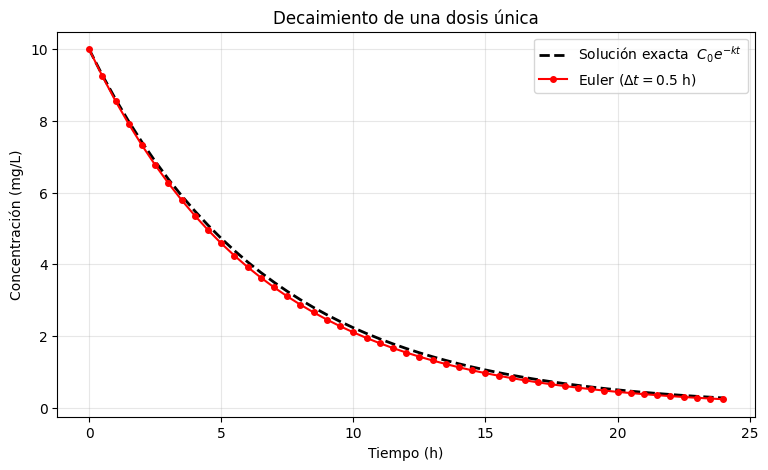

In [ ]:
k  = 0.15            # tasa de eliminación (1/h)
C0 = 10.0            # dosis inicial (mg/L)
T_final = 24         # horas a simular
dt = 0.5             # paso temporal (h)  — prueba luego 0.05 y 5.0

n_pasos = int(T_final / dt)
t = np.linspace(0, T_final, n_pasos + 1)
C = np.zeros(n_pasos + 1)
C[0] = C0

for n in range(n_pasos):
    derivada = -k * C[n]
    C[n+1] = None    # <--- ¡Tu turno! Aplica la fórmula de Euler

# Comparamos con la solución exacta
C_exacta = C0 * np.exp(-k * t)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t, C_exacta, 'k--', lw=2, label='Solución exacta  $C_0 e^{-kt}$')
ax.plot(t, C, 'ro-', markersize=4, label=f'Euler ($\\Delta t={dt}$ h)')
ax.set_xlabel('Tiempo (h)'); ax.set_ylabel('Concentración (mg/L)')
ax.legend(); ax.grid(alpha=0.3); ax.set_title('Decaimiento de una dosis única')
plt.show()

<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

```python
C[n+1] = C[n] + dt * derivada
```
</details>

### 🛠️ ¡TU TURNO 2! — Dosificación periódica

Ahora simula que el paciente recibe **una dosis $D$ cada $T$ horas**. La dosificación se modela sumando $D$ a la concentración cada vez que toca tomarla.

Tu objetivo: encontrar un $(D, T)$ que mantenga la concentración dentro de la **ventana terapéutica** (entre 4 y 12 mg/L) durante 3 días.

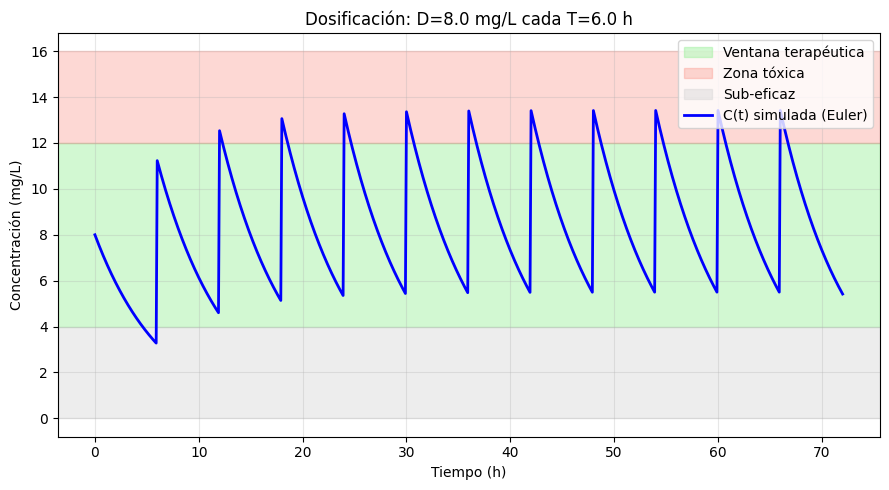

In [ ]:
k  = 0.15
D  = 8.0     # dosis (mg/L equivalente)
T  = 6.0     # intervalo entre dosis (h)
T_final = 72
dt = 0.1

n_pasos = int(T_final / dt)
t = np.linspace(0, T_final, n_pasos + 1)
C = np.zeros(n_pasos + 1)
t_next = 0.0   # cuándo toca la siguiente dosis

for n in range(n_pasos):
    if t[n] >= t_next:
        C[n] = C[n] + D     # se administra la dosis
        t_next += T
    derivada = -k * C[n]
    C[n+1] = None    # <--- ¡Tu turno! Aplica de nuevo Euler (es el mismo paso que antes)

dibujar_concentracion(t, C, titulo=f'Dosificación: D={D} mg/L cada T={T} h')

<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

```python
C[n+1] = C[n] + dt * derivada
```
(El paso de Euler es exactamente igual: la dosis solo cambia el valor inicial de cada tramo.)
</details>

### 🔍 Experimenta y Reflexiona

- **Cambia `dt`** en el TU TURNO 1 a 5.0 horas. ¿Qué le pasa al paciente virtual? ¿Sigue siendo válida la simulación?
- **Cambia `T`** a 12 h en el régimen de dosificación. ¿La concentración cae fuera de la ventana?
- **Tasa de eliminación**: prueba con `k = 0.05`. Con la misma dosis, ¿qué peligro aparece?

### 🌡️ Mapa de regímenes — ¿Qué combinaciones funcionan?

Ejecuta la celda siguiente para ver, en función de la dosis y el intervalo, qué regímenes mantienen al paciente dentro de la ventana terapéutica.

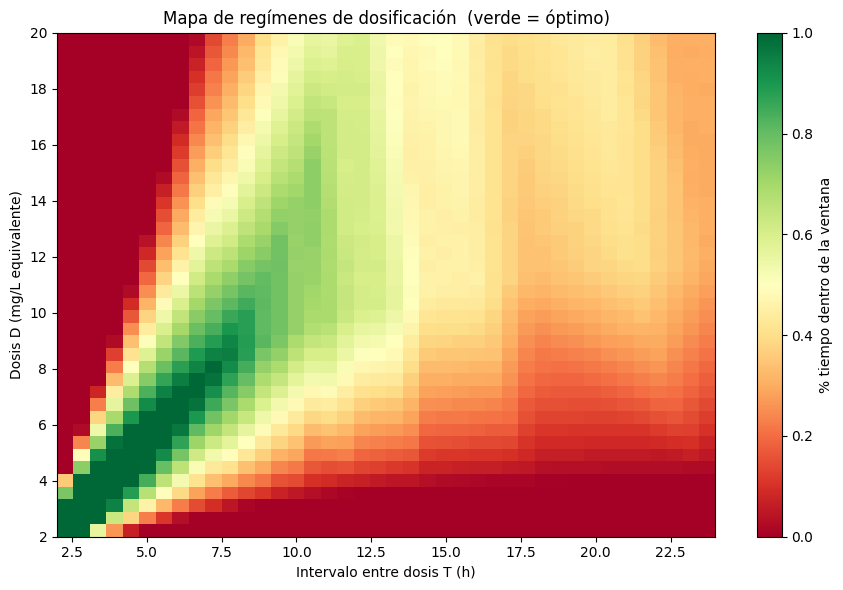

In [6]:
mapa_dosificacion(k=0.15)

---

## 📚 Referencias

**Wagner, J.G. (1993).** *Pharmacokinetics for the Pharmaceutical Scientist.* Technomic Publishing.

**Sheiner, L.B. & Beal, S.L. (1980).** *Evaluation of methods for estimating population pharmacokinetic parameters.* Journal of Pharmacokinetics and Biopharmaceutics, 8(6), 553–571.  
[→ DOI: 10.1007/BF01060053](https://doi.org/10.1007/BF01060053)

**Euler, L. (1768).** *Institutionum calculi integralis.* (origen del método de Euler)

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---